# Task 1

In [1]:
WIDTHS = [x for x in range(4, 33)] 

In [2]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from transformers import AutoModelForSequenceClassification

from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint("../saves/tutorial_2_lora")

from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)



# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `to

Evaluation accuracy: 0.83352


In [3]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")


/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.8158


In [4]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")


Step,Training Loss
500,0.409500
1000,0.399700
1500,0.413900
2000,0.386100
2500,0.387900
3000,0.393400


Evaluation accuracy: 0.84024


In [5]:
from pathlib import Path

mg.export("../saves/tutorial_3_qat")

INFO     Exporting MaseGraph to .pt, .mz
INFO     Exporting GraphModule to .pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to .mz


## Lab 4

In [9]:
from pathlib import Path
from chop import MaseGraph

In [10]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is 

KeyboardInterrupt: 

In [ ]:
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.452300
1000,0.419500
1500,0.430200
2000,0.405000
2500,0.402200
3000,0.408100
3500,0.423300
4000,0.416100
4500,0.390700
5000,0.398300


Evaluation accuracy: 0.83408


In [ ]:
from pathlib import Path

mg.export("../saves/tutorial_4_pruned")

## PTQ Iterations

In [11]:
import chop.passes as passes

def get_quantisation_config(width):
    quantization_config = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": width,
                "data_in_frac_width": width//2,
                # weight
                "weight_width": width,
                "weight_frac_width": width//2,
                # bias
                "bias_width": width,
                "bias_frac_width": width//2,
            }
        },
    }
    return quantization_config



In [12]:


ptq_accuracies = []
qat_accuracies = []

for width in WIDTHS:
    mg = MaseGraph.from_checkpoint("../saves/tutorial_2_lora")
    mg, _ = passes.quantize_transform_pass(mg,pass_args=get_quantisation_config(width),)
    trainer = get_trainer(
        model=mg.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    eval_results = trainer.evaluate()
    print(f"Evaluation accuracy: {eval_results['eval_accuracy']}, Bit Width: {width}")
    ptq_accuracies.append(eval_results['eval_accuracy'])

    trainer.train()
    eval_results = trainer.evaluate()
    print(f"Evaluation accuracy: {eval_results['eval_accuracy']}, Bit Width: {width}")
    qat_accuracies.append(eval_results['eval_accuracy'])

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.5, Bit Width: 4


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


Evaluation accuracy: 0.5, Bit Width: 4


...

Evaluation accuracy: 0.84184, Bit Width: 31


/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83352, Bit Width: 32


Step,Training Loss
500,0.397700
1000,0.396400
1500,0.404500
2000,0.375200
2500,0.378700
3000,0.388200


Evaluation accuracy: 0.84192, Bit Width: 32


[0.5, 0.5, 0.56328, 0.56544, 0.8158, 0.8148, 0.82208, 0.82208, 0.83024, 0.83024, 0.83356, 0.83356, 0.83388, 0.83388, 0.83372, 0.83372, 0.8332, 0.8332, 0.8336, 0.8336, 0.83348, 0.83348, 0.83364, 0.83364, 0.83352, 0.83352, 0.83352, 0.83352, 0.83352]


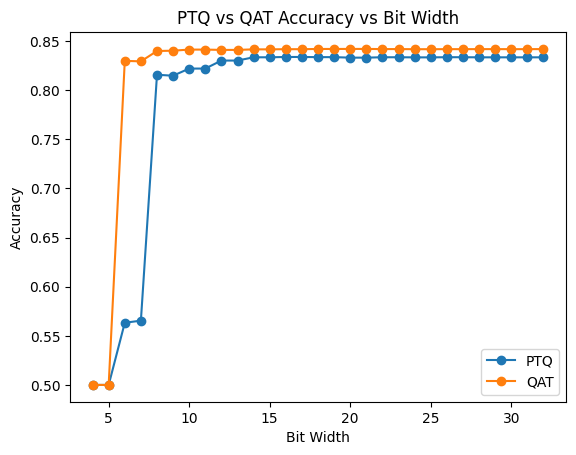

In [13]:
print(ptq_accuracies)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(WIDTHS, ptq_accuracies, marker='o', label="PTQ")
plt.plot(WIDTHS, qat_accuracies, marker='o', label="QAT")

plt.xlabel("Bit Width")
plt.ylabel("Accuracy")
plt.title("PTQ vs QAT Accuracy vs Bit Width")
plt.legend()
plt.show()


The best result looks to be bitwidth of 8, which happens to coencide with the model we already saved earlier

# Task 2


In [14]:
# PTQ 32 bit width
import numpy as np


SPARSITIES = np.arange(0.1, 1, 0.1)
pruned_accuracies = {"l1-norm": [],
                     "random" : []}
pruned_trained_accuracies = {"l1-norm": [],
                     "random" : []}
def get_pruning_config(sparsity, mode):
    pruning_config = {
        "weight": {
            "sparsity": sparsity,
            "method": mode,
            "scope": "local",
        },
        "activation": {
            "sparsity": sparsity,
            "method": mode,
            "scope": "local",
        },
    }
    return pruning_config


In [15]:


for mode in ["l1-norm", "random"]:
    for sparsity in SPARSITIES:
        mg = MaseGraph.from_checkpoint("../saves/tutorial_3_qat")
        mg, _ = passes.quantize_transform_pass(mg,pass_args=get_quantisation_config(32),)
        mg.model.to("cuda:0")
        mg, _ = passes.prune_transform_pass(mg, pass_args=get_pruning_config(sparsity, mode))
        mg.model.to("cuda:0")
        trainer = get_trainer(
            model=mg.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
            num_train_epochs=5,
        )
        # Evaluate accuracy
        eval_results = trainer.evaluate()
        print(f"Evaluation accuracy: {eval_results['eval_accuracy']}, Sparsity: {sparsity}")
        pruned_accuracies[mode].append(eval_results['eval_accuracy'])

        trainer.train()
        eval_results = trainer.evaluate()
        print(f"Evaluation accuracy: {eval_results['eval_accuracy']}, Sparsity: {sparsity}")
        pruned_trained_accuracies[mode].append(eval_results['eval_accuracy'])


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is 

Evaluation accuracy: 0.82264, Sparsity: 0.1


Step,Training Loss
500,0.394800
1000,0.390900
1500,0.404700
2000,0.376700
2500,0.381900
3000,0.387000
3500,0.396800
4000,0.380400
4500,0.362100
5000,0.367000


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Evaluation accuracy: 0.85896, Sparsity: 0.1


...

Evaluation accuracy: 0.499, Sparsity: 0.8


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier
/home/alex/Documents/yr_4/ADLS/ELEC70109-Advanced-Deep-Learning-Systems/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is 

Evaluation accuracy: 0.49872, Sparsity: 0.9


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693200
3500,0.693200
4000,0.693200
4500,0.693100
5000,0.693100


Evaluation accuracy: 0.49808, Sparsity: 0.9


In [5]:
# for some reason these were lost in the run, so deepseek has kindly extracted them from the print logs and i have added them here.

pruned_accuracies = {
    "l1-norm": [
        0.82264,  # Sparsity: 0.1
        0.82044,  # Sparsity: 0.2
        0.806,    # Sparsity: 0.3
        0.7406,   # Sparsity: 0.4
        0.64928,  # Sparsity: 0.5
        0.5248,   # Sparsity: 0.6
        0.511,    # Sparsity: 0.7
        0.49956,  # Sparsity: 0.8
        0.50076   # Sparsity: 0.9
    ],
    "random": [
        0.62132,  # Sparsity: 0.1
        0.50152,  # Sparsity: 0.2
        0.50104,  # Sparsity: 0.3
        0.50176,  # Sparsity: 0.4
        0.50012,  # Sparsity: 0.5
        0.50088,  # Sparsity: 0.6
        0.50008,  # Sparsity: 0.7
        0.501,    # Sparsity: 0.8
        0.49872   # Sparsity: 0.9
    ]
}

pruned_trained_accuracies = {
    "l1-norm": [
        0.85896,  # Sparsity: 0.1 (after training)
        0.85672,  # Sparsity: 0.2
        0.85228,  # Sparsity: 0.3
        0.84652,  # Sparsity: 0.4
        0.83656,  # Sparsity: 0.5
        0.82048,  # Sparsity: 0.6
        0.80572,  # Sparsity: 0.7
        0.70212,  # Sparsity: 0.8
        0.5432    # Sparsity: 0.9
    ],
    "random": [
        0.8376,   # Sparsity: 0.1 (after training)
        0.82224,  # Sparsity: 0.2
        0.80684,  # Sparsity: 0.3
        0.7864,   # Sparsity: 0.4
        0.7362,   # Sparsity: 0.5
        0.53144,  # Sparsity: 0.6
        0.49792,  # Sparsity: 0.7
        0.499,    # Sparsity: 0.8
        0.49808   # Sparsity: 0.9
    ]
}

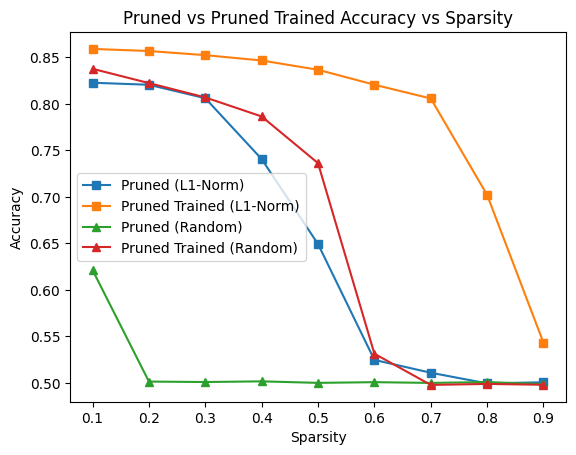

In [7]:
import matplotlib.pyplot as plt

SPARSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

plt.figure()
plt.plot(SPARSITIES, pruned_accuracies["l1-norm"], marker='s', label="Pruned (L1-Norm)")
plt.plot(SPARSITIES, pruned_trained_accuracies["l1-norm"], marker='s', label="Pruned Trained (L1-Norm)")
plt.plot(SPARSITIES, pruned_accuracies["random"], marker='^', label="Pruned (Random)")
plt.plot(SPARSITIES, pruned_trained_accuracies["random"], marker='^', label="Pruned Trained (Random)")

plt.xlabel("Sparsity")
plt.ylabel("Accuracy")
plt.title("Pruned vs Pruned Trained Accuracy vs Sparsity")
plt.legend()
plt.show()


In [ ]:
# I don't believe we will need to save this for later, so haven't filled this in.

from pathlib import Path

# mg.export("../saves/tutorial_3_prubed")